In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings("ignore")


# Plot styles
plt.rcParams.update({
    "figure.dpi":150,
    "font.family":"sans-serif",
    "axes.spines.top":False,
    "axes.spines.right":False,
})

os.makedirs("../figures",exist_ok=True)
df = pd.read_csv("../data/processed/solid_electrolyte_features.csv")

df["ion_type"] = "Li" 
df.loc[df["na_fraction"]>0,"ion_type"] = "Na"
df.loc[(df["li_fraction"]>0) & (df["na_fraction"]>0),"ion_type"] = "Both"

print(f"Dataset loaded: {df.shape}")
print(df.head())

Dataset loaded: (15362, 21)
  material_id formula  band_gap  energy_above_hull  formation_energy_per_atom  \
0   mp-995393    LiS4    2.1989           0.000000                  -0.612185   
1     mp-2659    LiN3    3.6364           0.000000                  -0.205822   
2    mp-27687    LiP7    1.6882           0.000000                  -0.190701   
3  mp-1185319    LiCl    5.7373           0.003853                  -2.021953   
4   mp-570935     LiI    4.3818           0.000000                  -1.422324   

        volume   density  nsites  nelements spacegroup  ... li_fraction  \
0  2115.078462  0.212291      10          2         P1  ...       0.200   
1    42.087708  1.931724       4          2       C2/m  ...       0.250   
2  1357.367140  2.189874      64          2   I4_1/acd  ...       0.125   
3    84.810010  1.660108       4          2     P6_3mc  ...       0.500   
4   130.391497  3.409051       4          2     P6_3mc  ...       0.500   

   na_fraction  mean_atomic_number

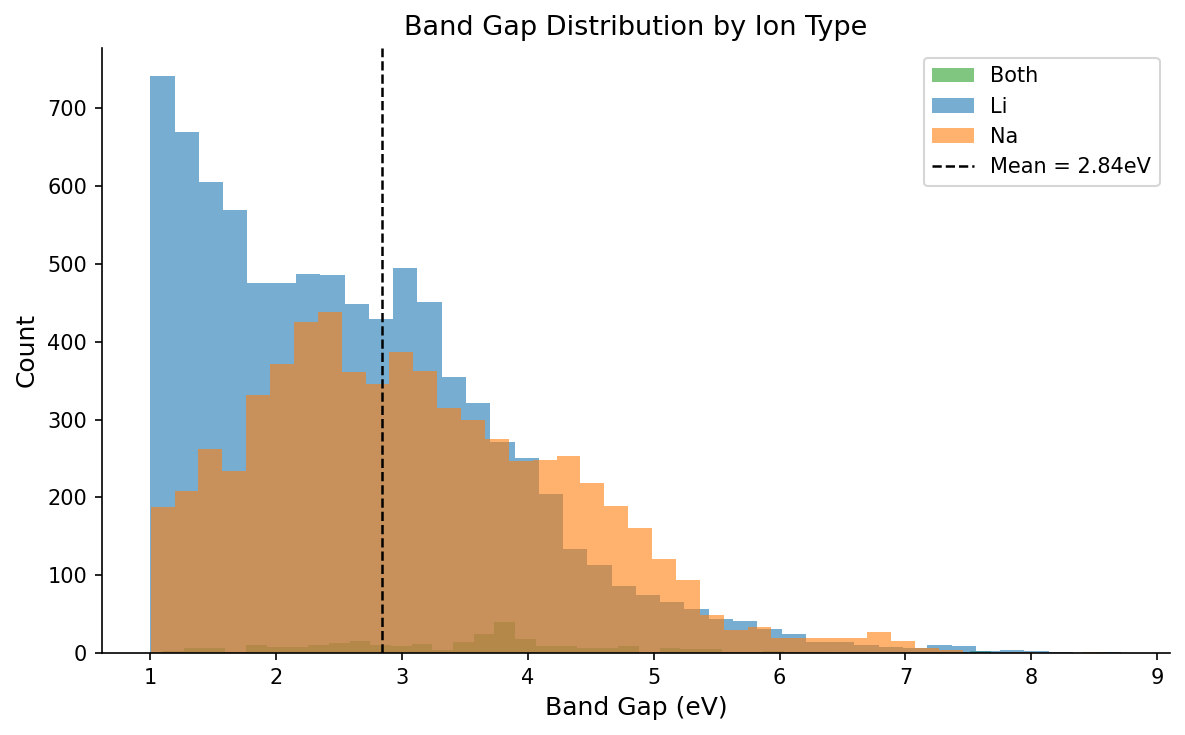

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
colors = {"Li":"#1f77b4", "Na":"#ff7f0e", "Both":"#2ca02c"}
for ion, group in df.groupby("ion_type"):
    ax.hist(group["band_gap"],bins=40,alpha=0.6,label=ion,color=colors[ion],edgecolor="none")
ax.axvline(df["band_gap"].mean(),color="black",linestyle="--",linewidth=1.2,label=f"Mean = {df['band_gap'].mean():.2f}eV")

ax.set_xlabel("Band Gap (eV)",fontsize=12)
ax.set_ylabel("Count",fontsize=12)
ax.set_title("Band Gap Distribution by Ion Type",fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../figures/band_gap_distribution.png")
plt.show()

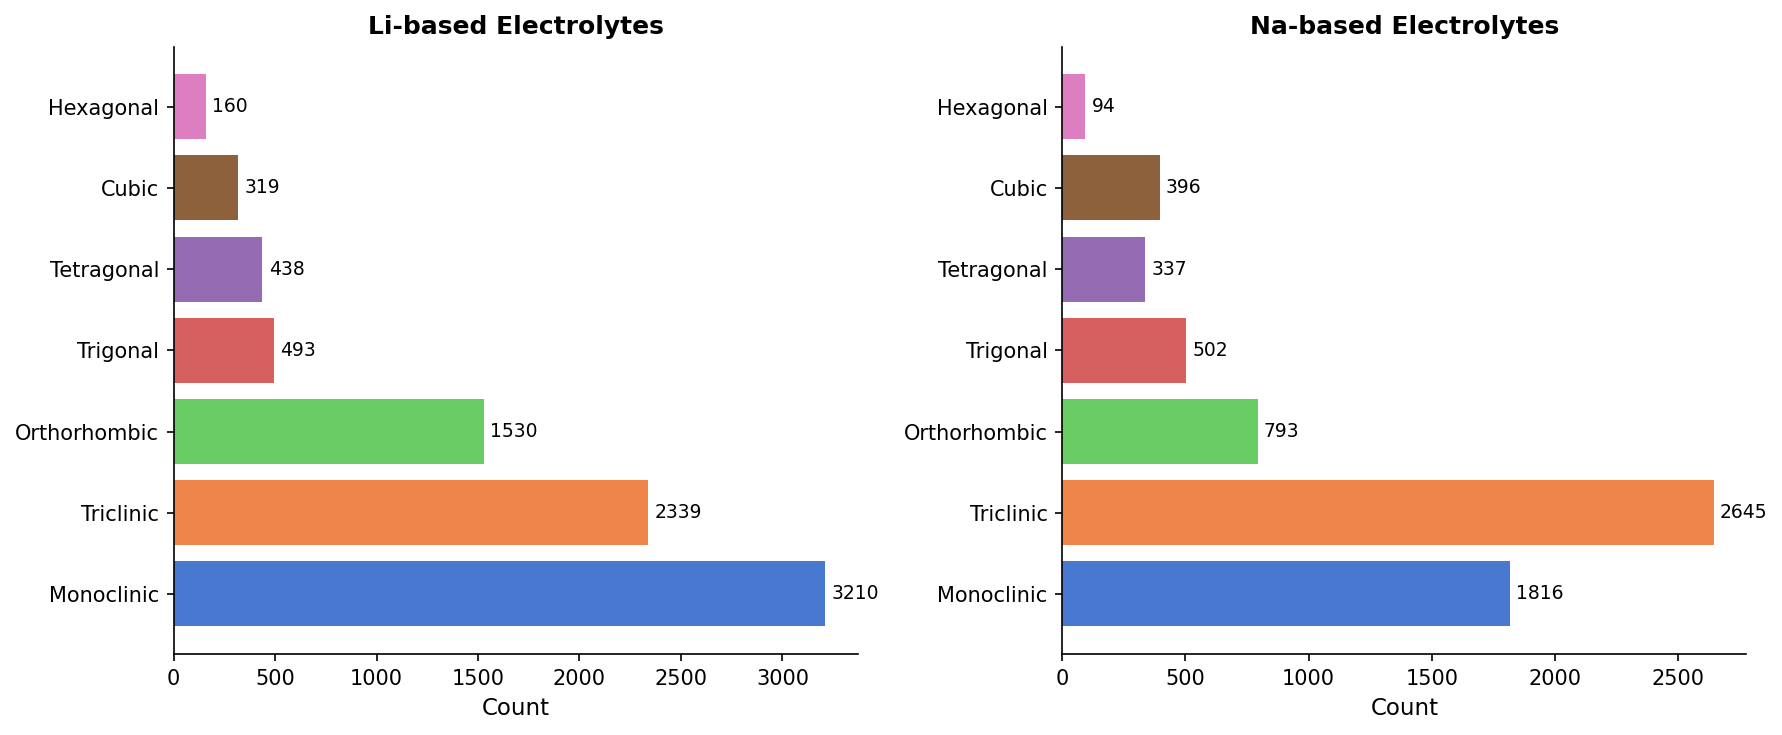

Saved fig02_crystal_systems.png


In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
crystal_order = df["crystal_system"].value_counts().index.tolist()
palette = sns.color_palette("muted",len(crystal_order))

for ax, ion in zip(axes,["Li","Na"]):
    subset = df[df["ion_type"]==ion]
    counts = subset["crystal_system"].value_counts().reindex(crystal_order, fill_value=0)
    bars = ax.barh(counts.index, counts.values, color=palette)
    ax.set_title(f"{ion}-based Electrolytes",fontsize=12,fontweight="bold")
    ax.set_xlabel("Count",fontsize=11)
    ax.bar_label(bars,padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("../figures/crystal_system_distribution.png")
plt.show()
print("Saved fig02_crystal_systems.png")

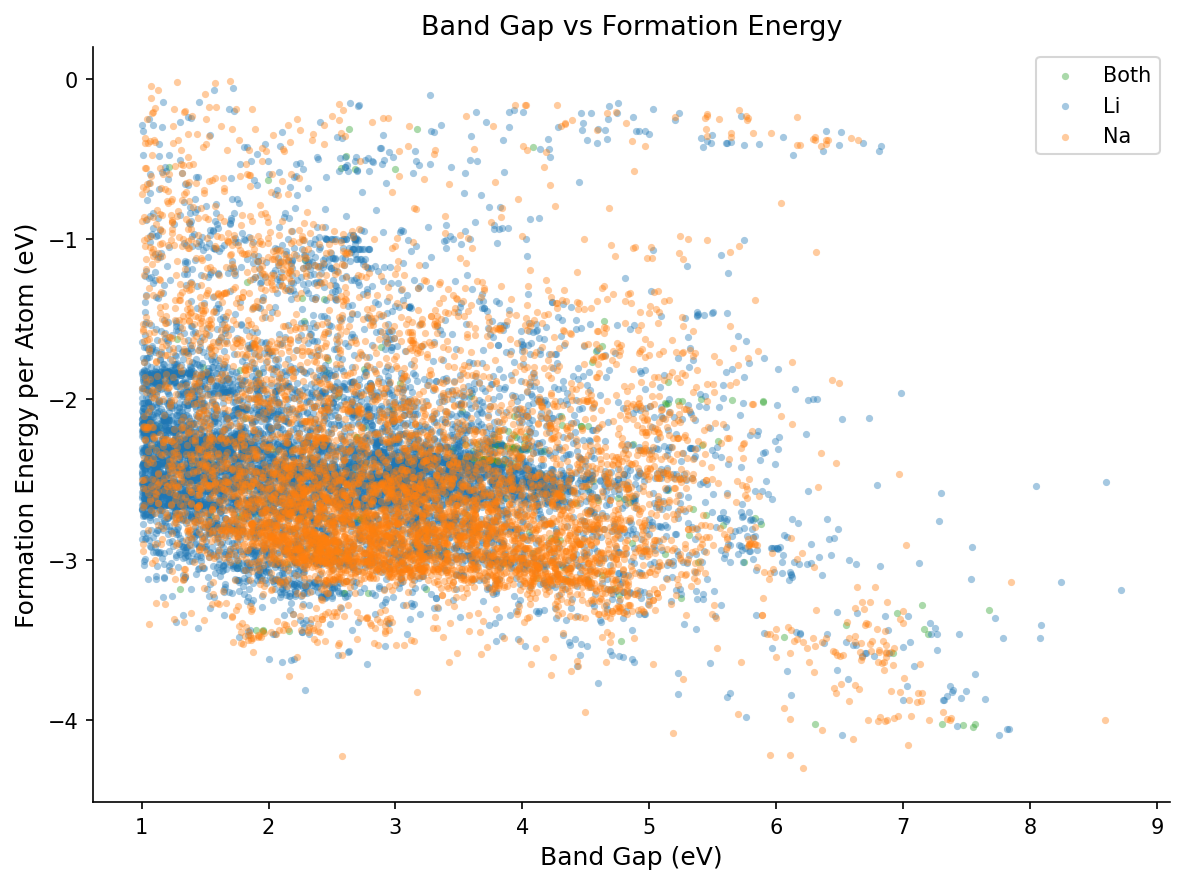

Saved fig03_band_gap_vs_formation_energy.png


In [7]:
fig, ax = plt.subplots(figsize=(8,6))
for ion, group in df.groupby("ion_type"):
    ax.scatter( 
        group["band_gap"],
        group["formation_energy_per_atom"],
        alpha=0.4,s=12,label=ion, 
        color=colors[ion],linewidths=0 
    )

ax.set_xlabel("Band Gap (eV)",fontsize=12)
ax.set_ylabel("Formation Energy per Atom (eV)",fontsize=12)
ax.set_title("Band Gap vs Formation Energy",fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../figures/fig03_band_gap_vs_formation_energy.png")
plt.show()
print("Saved fig03_band_gap_vs_formation_energy.png")

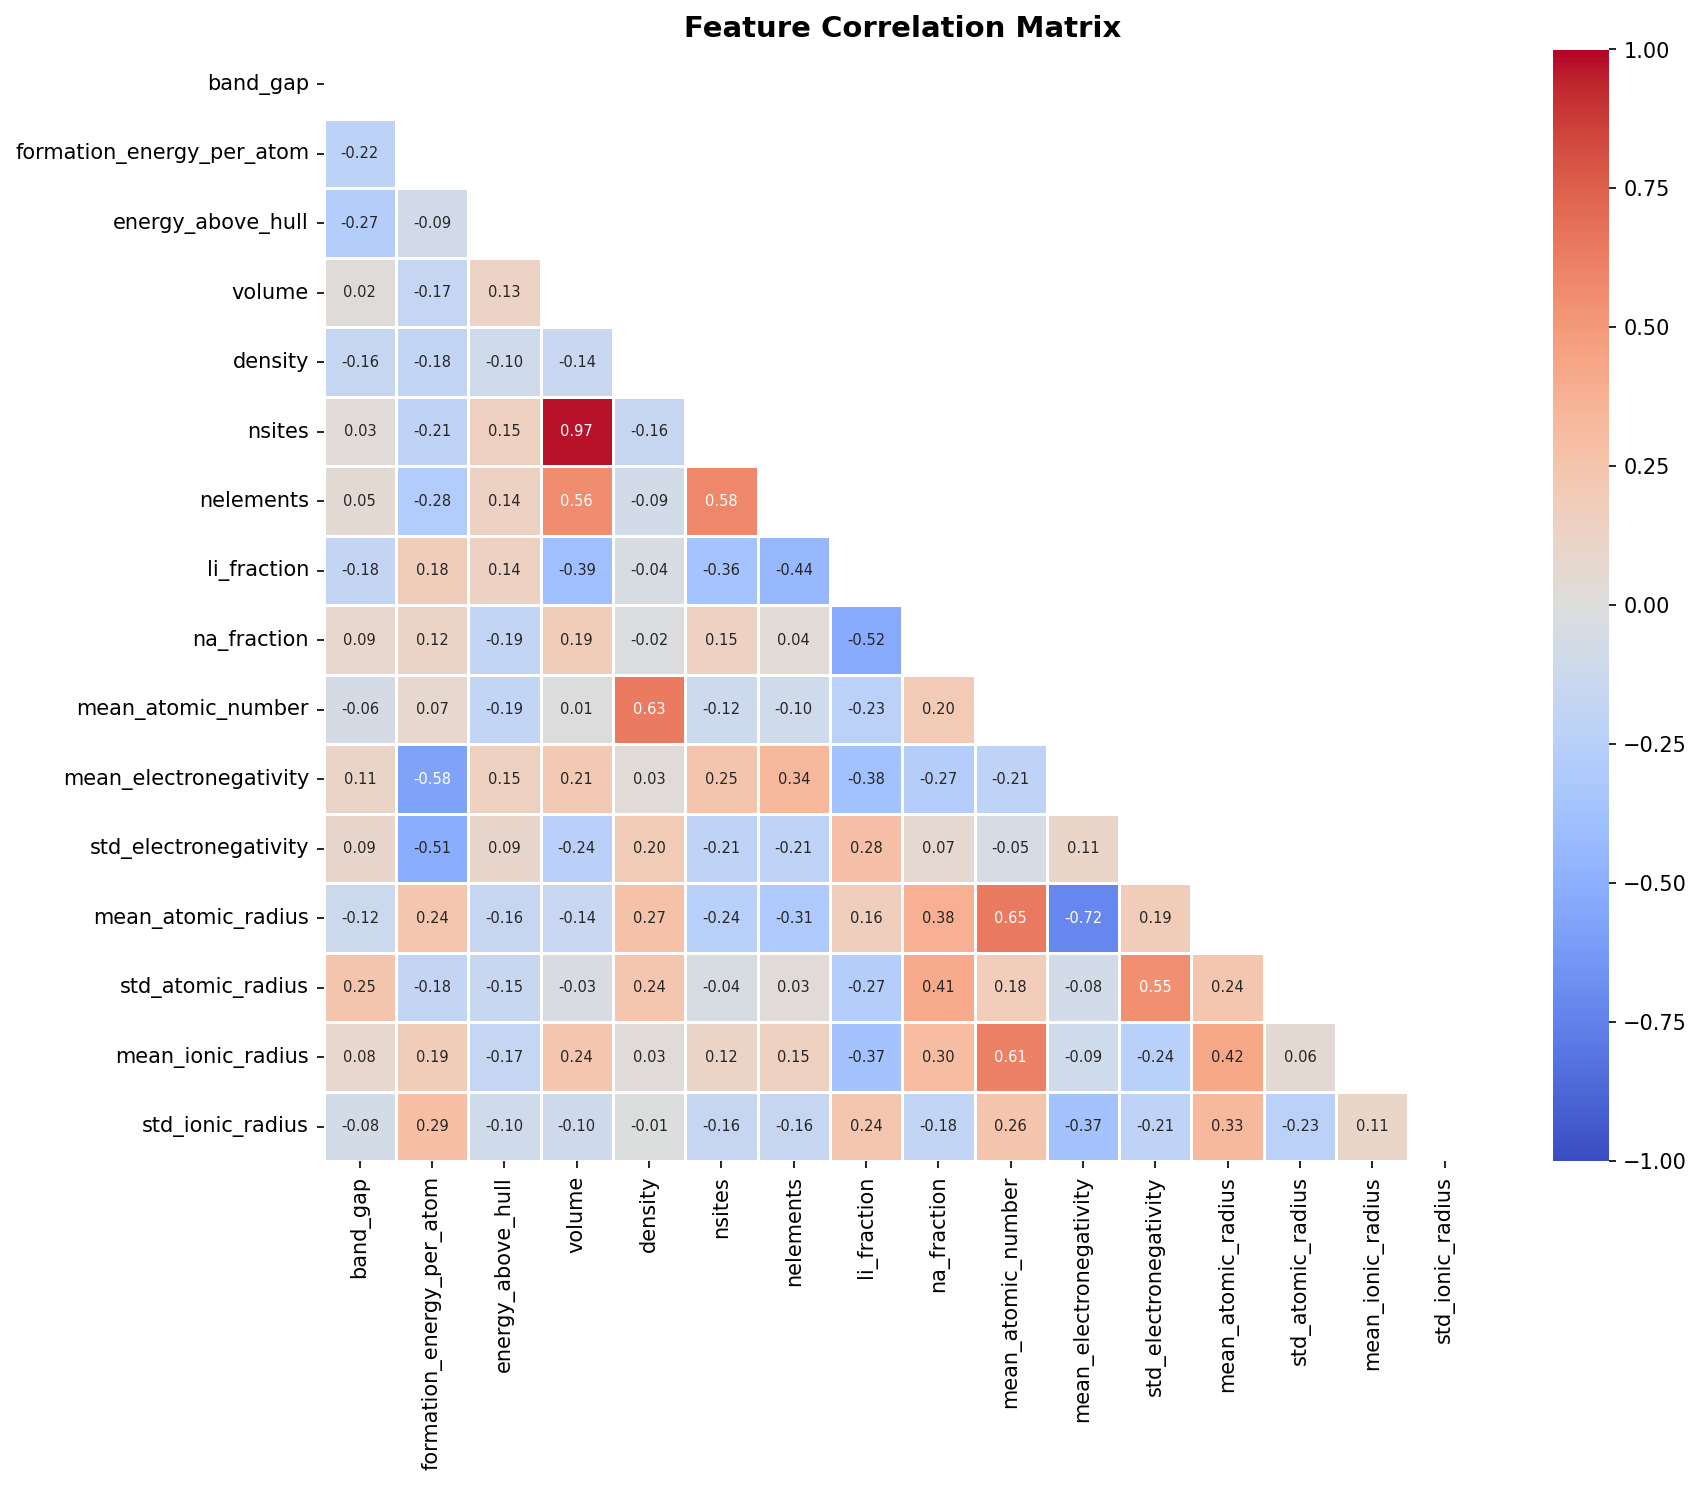

Saved fig04_feature_correlation_heatmap.png


In [10]:
numeric_cols = [
    "band_gap", "formation_energy_per_atom","energy_above_hull", 
    "volume","density","nsites","nelements",
    "li_fraction","na_fraction", 
    "mean_atomic_number","mean_electronegativity","std_electronegativity",
    "mean_atomic_radius","std_atomic_radius",
    "mean_ionic_radius","std_ionic_radius",
]

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap( 
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1,linewidths=0.5, ax=ax, annot_kws={"size":7}
)

ax.set_title("Feature Correlation Matrix",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig04_feature_correlation_heatmap.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig04_feature_correlation_heatmap.png")

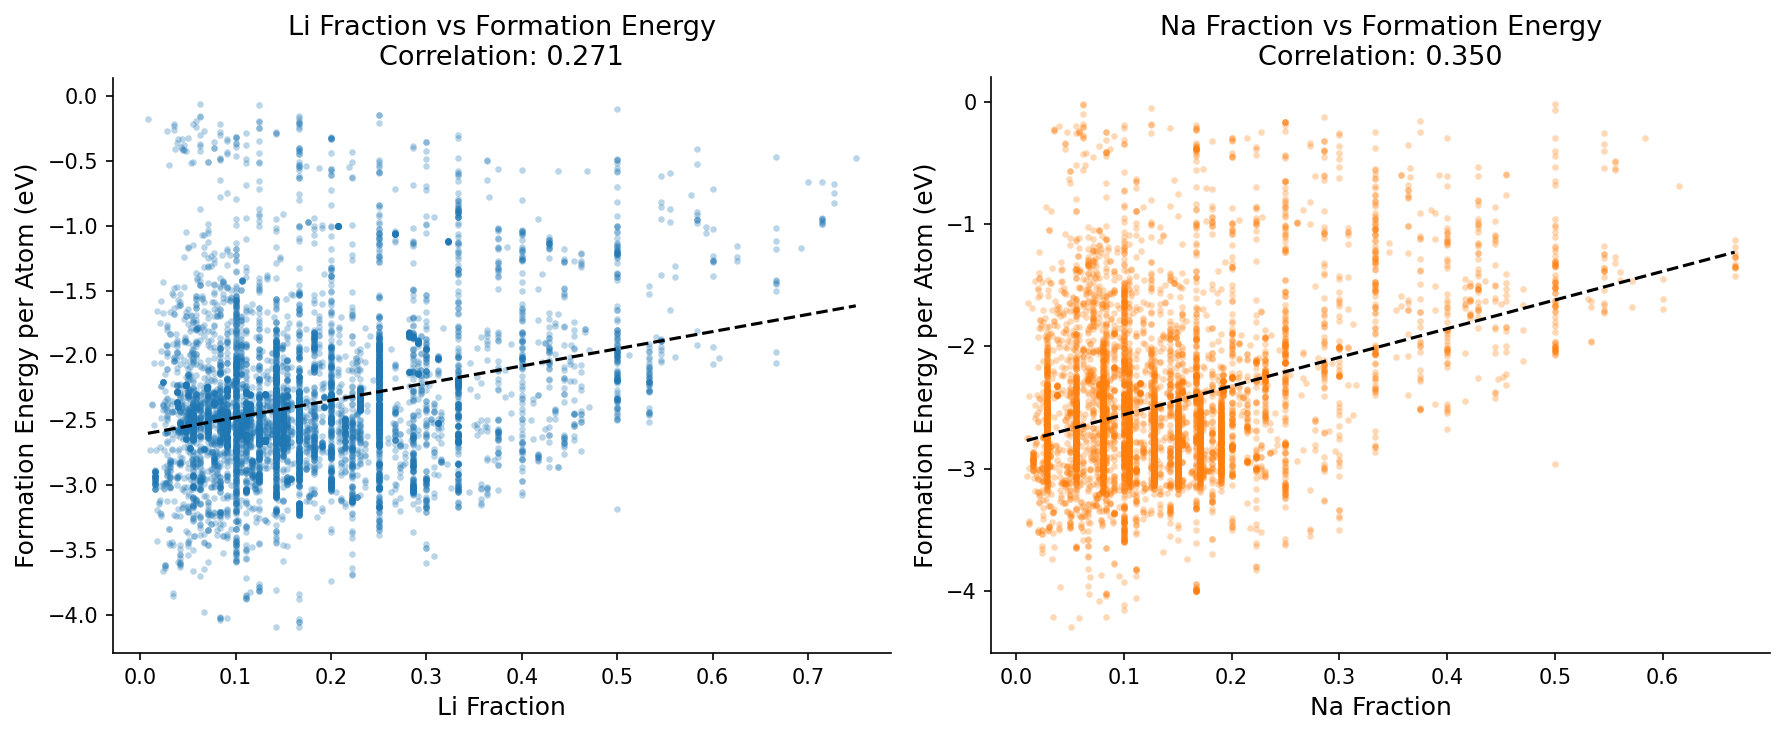

Saved fig05_ion_fraction_vs_formation_energy.png


In [12]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, (col,label,color) in zip(axes, [
    ("li_fraction","Li Fraction","#1f77b4"),
    ("na_fraction","Na Fraction","#ff7f0e"),    
]):
    subset = df[df[col]>0]
    ax.scatter(subset[col],subset["formation_energy_per_atom"],
               alpha=0.3,s=10,color=color,linewidths=0)
    # Trend Line
    z = np.polyfit(subset[col],subset["formation_energy_per_atom"],1)
    p = np.poly1d(z)
    x_line = np.linspace(subset[col].min(),subset[col].max(),100)
    ax.plot(x_line, p(x_line),color="black",linewidth=1.5, linestyle="--")

    r = subset[[col,"formation_energy_per_atom"]].corr().iloc[0,1]
    ax.set_xlabel(label,fontsize=12)
    ax.set_ylabel("Formation Energy per Atom (eV)",fontsize=12)
    ax.set_title(f"{label} vs Formation Energy\nCorrelation: {r:.3f}",fontsize=13)

plt.tight_layout()
plt.savefig("../figures/fig05_ion_fraction_vs_formation_energy.png",dpi=150)
plt.show()
print("Saved fig05_ion_fraction_vs_formation_energy.png")   

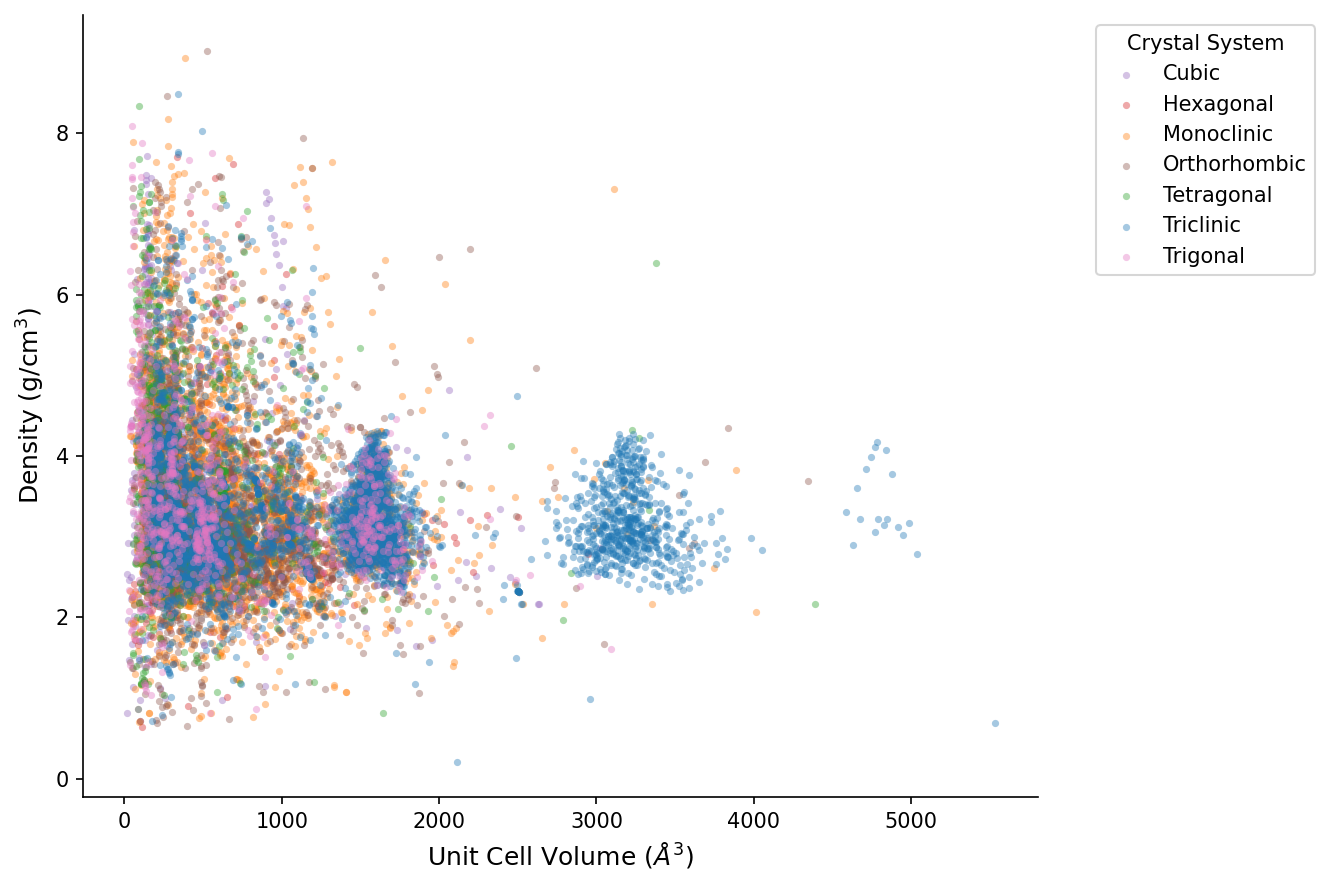

Saved fig06_volume_vs_density_by_crystal_system.png


In [13]:
fig, ax = plt.subplots(figsize=(9,6))
crystal_systems = df["crystal_system"].unique()
palette = dict(zip(crystal_systems,sns.color_palette("tab10",len(crystal_systems))))

for system, group in df.groupby("crystal_system"):
    ax.scatter(group["volume"], group["density"],
               alpha=0.4, s=12, label=system, color=palette[system], linewidths=0)
    
ax.set_xlabel("Unit Cell Volume ($\AA^3$)",fontsize=12)
ax.set_ylabel("Density (g/cm$^3$)",fontsize=12)
ax.legend(title="Crystal System", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("../figures/fig06_volume_vs_density_by_crystal_system.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig06_volume_vs_density_by_crystal_system.png")

In [14]:
known_electrolytes = {
    "LLZO":["Li","La","Zr","O"],
    "LGPS":["Li","Ge","P","S"],
    "NASICON":["Na","Zr","Si","O"],
    "Argyrodite:":["Li","P","S"],
}

def flag_family(formula):
    for family, elements in known_electrolytes.items():
        if all(e1 in formula for e1 in elements):
            return family
    return "Other"

df["electrolyte_family"] = df["formula"].apply(flag_family)
print("Electrolyte families flagged:")
print(df["electrolyte_family"].value_counts())

Electrolyte families flagged:
electrolyte_family
Other          14763
Argyrodite:      314
NASICON          279
LGPS               5
LLZO               1
Name: count, dtype: int64


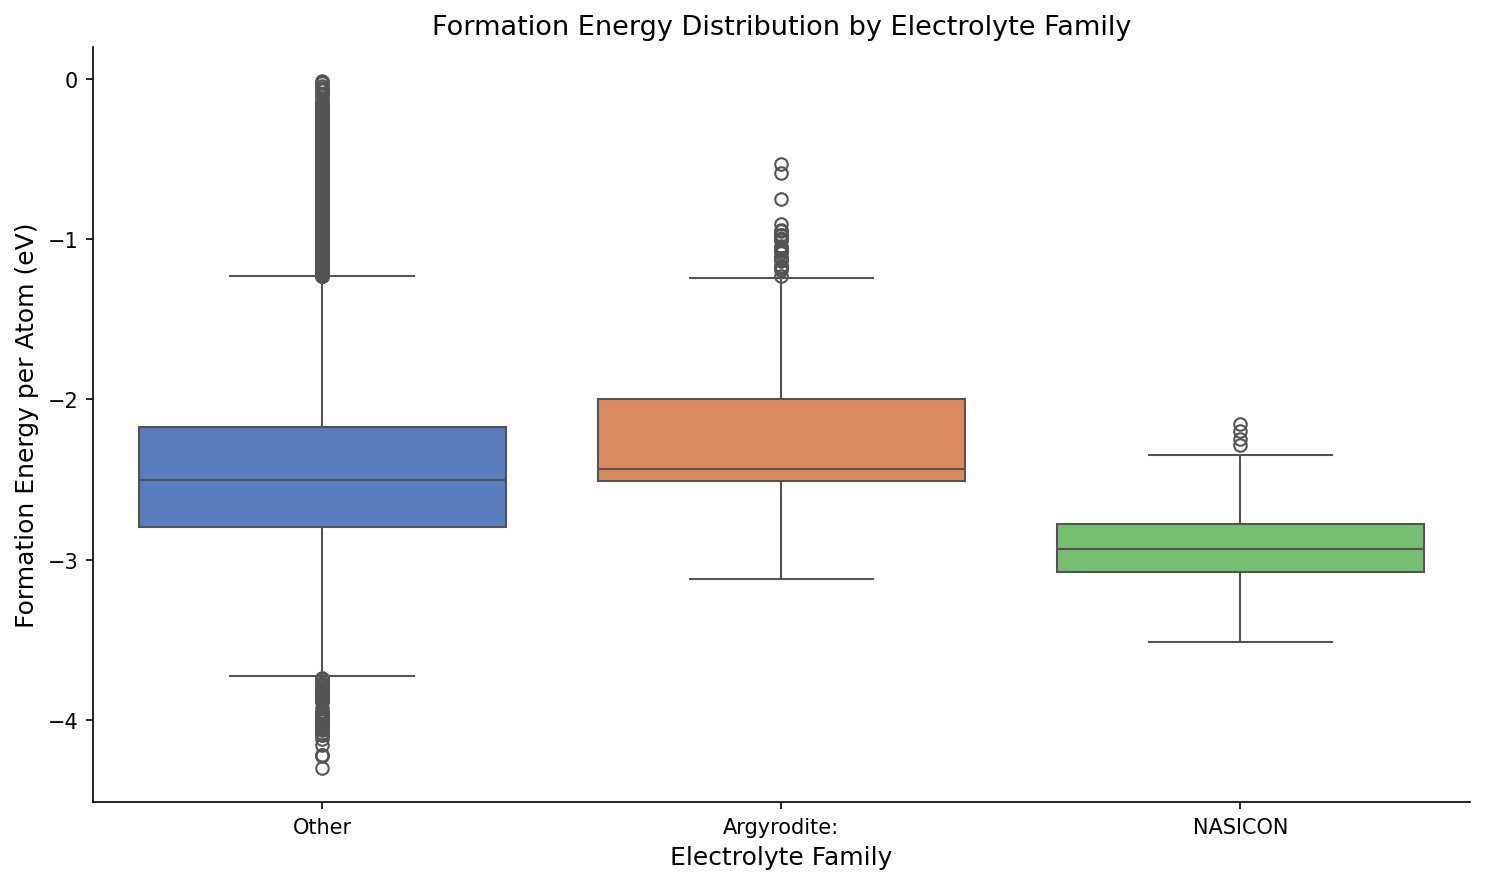

Saved fig07_formation_energy_by_family.png


In [15]:
family_counts = df["electrolyte_family"].value_counts()
familes_to_plot = family_counts[family_counts>10].index.tolist()
df_plot = df[df["electrolyte_family"].isin(familes_to_plot)]

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(
    data=df_plot, x="electrolyte_family", y="formation_energy_per_atom", 
    palette="muted", ax=ax,order=familes_to_plot
)
ax.set_xlabel("Electrolyte Family",fontsize=12)
ax.set_ylabel("Formation Energy per Atom (eV)",fontsize=12)
ax.set_title("Formation Energy Distribution by Electrolyte Family",fontsize=13)

plt.tight_layout()
plt.savefig("../figures/fig07_formation_energy_by_family.png",dpi=150)
plt.show()
print("Saved fig07_formation_energy_by_family.png")

In [16]:
print("=== EDA Summary ===")
print(f"\nTotal materials: {len(df)}")
print(f"Li-only: {(df['ion_type'] == 'Li').sum()}")
print(f"Na-only: {(df['ion_type'] == 'Na').sum()}")
print(f"Both: {(df['ion_type'] == 'Both').sum()}")

print(f"\nBand gap stats:")
print(df.groupby("ion_type")["band_gap"].describe().round(2))

print(f"\nFormation energy stats:")
print(df.groupby("ion_type")["formation_energy_per_atom"].describe().round(2))

print(f"\nTop correlations with band_gap:")
corr_with_bg = df[numeric_cols].corr()["band_gap"].drop("band_gap").sort_values(key=abs, ascending=False)
print(corr_with_bg.head(8).round(3))

# Save updated dataframe with family labels
df.to_csv("../data/processed/solid_electrolyte_features.csv", index=False)
print("\nUpdated processed CSV saved with electrolyte family labels.")
print("\nPhase 2 complete.")

=== EDA Summary ===

Total materials: 15362
Li-only: 8489
Na-only: 6583
Both: 290

Band gap stats:
           count  mean   std  min   25%   50%   75%   max
ion_type                                                 
Both       290.0  3.58  1.30  1.1  2.67  3.64  4.09  7.68
Li        8489.0  2.61  1.21  1.0  1.61  2.44  3.34  8.72
Na        6583.0  3.10  1.23  1.0  2.16  2.96  3.96  8.59

Formation energy stats:
           count  mean   std   min   25%   50%   75%   max
ion_type                                                  
Both       290.0 -2.45  0.57 -4.04 -2.74 -2.38 -2.29 -0.31
Li        8489.0 -2.38  0.54 -4.10 -2.66 -2.46 -2.18 -0.06
Na        6583.0 -2.46  0.67 -4.30 -2.91 -2.62 -2.16 -0.01

Top correlations with band_gap:
energy_above_hull           -0.273
std_atomic_radius            0.249
formation_energy_per_atom   -0.222
li_fraction                 -0.180
density                     -0.157
mean_atomic_radius          -0.123
mean_electronegativity       0.113
std_electrone